Objective

Estimate the production cost of each concrete mix using the material quantities in the dataset and the reference material costs.

In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [15]:
# Load the Dataset
data = pd.read_csv("../dataset/clean_concrete_dataset.csv")

data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [16]:
# Load the Cost Reference Table
cost_reference = pd.read_csv("../dataset/material_cost_reference.csv")

cost_reference

,Material,Unit,Cost_per_kg_INR
0,Cement,kg,8.50
1,Blast Furnace Slag,kg,3.00
2,Fly Ash,kg,2.00
3,Water,kg,0.05
4,Superplasticizer,kg,120.00
5,Coarse Aggregate,kg,1.20
6,Fine Aggregate,kg,1.00


In [17]:
# Create a Cost Dictionary
cost_dict = dict(zip(cost_reference["Material"],
                     cost_reference["Cost_per_kg_INR"]))

cost_dict

{'Cement': 8.5,
 'Blast Furnace Slag': 3.0,
 'Fly Ash': 2.0,
 'Water': 0.05,
 'Superplasticizer': 120.0,
 'Coarse Aggregate': 1.2,
 'Fine Aggregate': 1.0}

In [18]:
# Calculate Material Cost
data["Material_Cost_INR"] = (
    data["Cement"] * cost_dict["Cement"] +
    data["Blast Furnace Slag"] * cost_dict["Blast Furnace Slag"] +
    data["Fly Ash"] * cost_dict["Fly Ash"] +
    data["Water"] * cost_dict["Water"] +
    data["Superplasticizer"] * cost_dict["Superplasticizer"] +
    data["Coarse Aggregate"] * cost_dict["Coarse Aggregate"] +
    data["Fine Aggregate"] * cost_dict["Fine Aggregate"]
)

data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48


In [19]:
# View Cost Statistics
data["Material_Cost_INR"].describe()

count     1005.000000
mean      5370.601766
std       1102.919827
min       3342.000000
25%       4648.155000
50%       5097.530000
75%       5933.215000
max      10072.010000
Name: Material_Cost_INR, dtype: float64

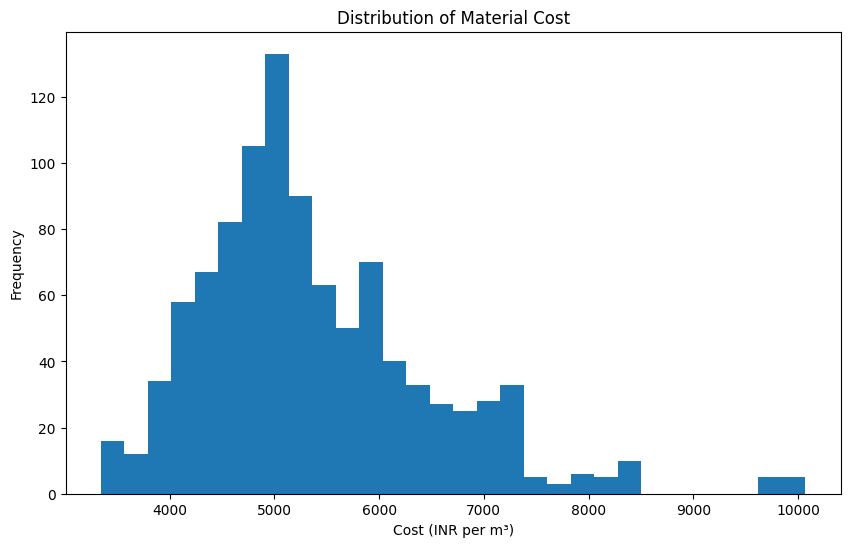

In [20]:
# Visualize Cost Distribution
plt.hist(data["Material_Cost_INR"], bins=30)

plt.title("Distribution of Material Cost")

plt.xlabel("Cost (INR per m³)")

plt.ylabel("Frequency")

plt.show()

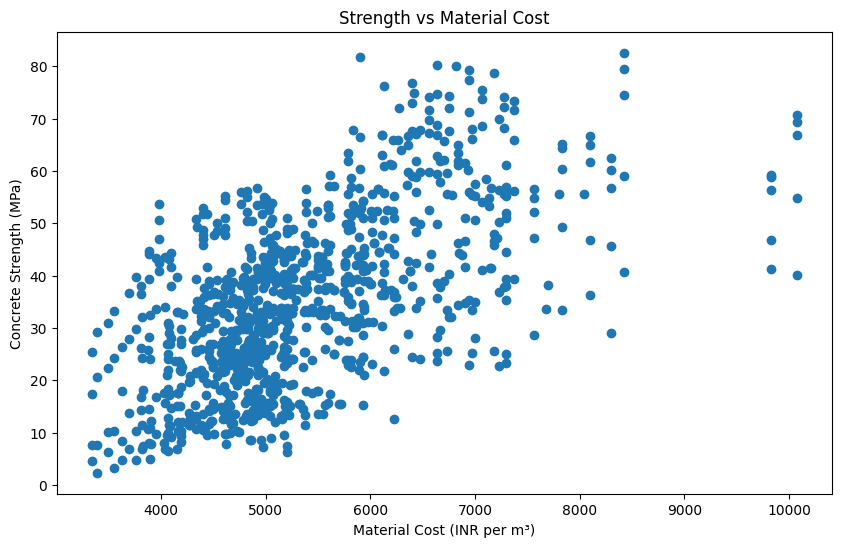

In [21]:
# Strength vs Cost
plt.scatter(
    data["Material_Cost_INR"],
    data["Strength"]
)

plt.xlabel("Material Cost (INR per m³)")

plt.ylabel("Concrete Strength (MPa)")

plt.title("Strength vs Material Cost")

plt.show()

In [22]:
# Save the Updated Dataset
data.to_csv(
    "../results/concrete_with_cost.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


## Observations

- A material cost estimation module was successfully implemented using the concrete mix proportions and a reference material cost table.

- The estimated material cost for each concrete mix was calculated by multiplying the quantity of each constituent material with its corresponding unit cost.

- The estimated material cost ranges from **₹3342.00/m³** to **₹10072.01/m³**, with an **average cost of ₹5414.71/m³**.

- The histogram indicates that most concrete mixes have material costs between **₹4500/m³ and ₹6000/m³**, while relatively few mixes fall at the lower and higher cost extremes.

- The Strength vs. Material Cost scatter plot suggests a general positive relationship, indicating that higher-strength concrete mixes often require higher material costs due to increased cement content and the use of admixtures.

- The calculated material cost provides an additional evaluation criterion that can be integrated with compressive strength prediction to support cost-effective concrete mix optimization.